### Neuronales Netzwerk zur Klassifizierung des AI4I 2020 Predictive Maintenance Datasets

Dieser Notebook implementiert ein neuronales Netzwerk (MLP) in TensorFlow/Keras zur Klassifizierung des 'AI4I 2020 Predictive maintenance dataset' ('ai4i2020.csv'). Es werden strenge Maßnahmen zur Vermeidung von Overfitting und Datenlecks angewendet.

In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import sys

### 1. Daten laden

In [11]:
# Annahme: Die Datei 'ai4i2020.csv' befindet sich im aktuellen Verzeichnis oder im Colab-Filesystem.
try:
    df = pd.read_csv('ai4i2020.csv')
except FileNotFoundError:
    print("Die Datei 'ai4i2020.csv' wurde nicht gefunden. Bitte stellen Sie sicher, dass sie hochgeladen wurde.")
    # Example: If the file is in a specific path, adjust it here.
    # df = pd.read_csv('/path/to/ai4i2020.csv')
    sys.exit(1) # Beendet das Skript, wenn die Datei nicht gefunden wird.

print("Originaldaten:")
display(df.head())
print("\nDatensatz-Informationen:")
df.info()

Originaldaten:


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



Datensatz-Informationen:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dt

### 2. Vorverarbeitung & Feature Selection

- Entfernung eindeutiger Identifikatoren (`'UDI'`, `'Product ID'`).
- Entfernung spezifischer Ausfallursachen (`'TWF'`, `'HDF'`, `'PWF'`, `'OSF'`, `'RNF'`) aus den Features, da diese direkten Aufschluss über 'Machine failure' geben würden.
- Definition der Zielvariable (`'Machine failure'`).
- One-Hot-Encoding der Spalte `'Type'`.

In [12]:
# Identifikatoren entfernen
df = df.drop(columns=['UDI', 'Product ID'])

# Features (X) und Zielvariable (y) definieren
X = df.drop(columns=['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df['Machine failure']

# Kategorische und numerische Spalten identifizieren
categorical_features = ['Type']
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
numerical_features = [col for col in numerical_features if col not in ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']]

print("Features nach Auswahl:", X.columns.tolist())
print("Zielvariable:", y.name)
print("Numerische Features:", numerical_features)
print("Kategorische Features:", categorical_features)

Features nach Auswahl: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Zielvariable: Machine failure
Numerische Features: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Kategorische Features: ['Type']


### 3. Train-Test-Split & Skalierung

- Die Daten werden in Training (80%) und Test (20%) aufgeteilt, wobei `stratify=y` verwendet wird, um die Klassenverteilung beizubehalten.
- `StandardScaler` wird nur auf den Trainingsdaten (`fit_transform`) trainiert und dann auf die Testdaten (`transform`) angewendet, um Data Leakage zu verhindern.
- `OneHotEncoder` wird ebenfalls auf die 'Type'-Spalte angewendet.

In [13]:
# Train-Test-Split mit Stratifizierung
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Anzahl der Trainingsdaten: {X_train.shape[0]}")
print(f"Anzahl der Testdaten: {X_test.shape[0]}")
print(f"Klassenverteilung Training (0/1): {np.bincount(y_train)}")
print(f"Klassenverteilung Test (0/1): {np.bincount(y_test)}")

# Preprocessing Pipeline
# Skaliert numerische Features und One-Hot-Encodiert kategorische Features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Anpassung des Preprocessors an die Trainingsdaten und Transformation beider Datensätze
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Ausgabe der Dimensionen der verarbeiteten Daten
print(f"\nDimensionen der verarbeiteten Trainingsdaten: {X_train_processed.shape}")
print(f"Dimensionen der verarbeiteten Testdaten: {X_test_processed.shape}")

Anzahl der Trainingsdaten: 8000
Anzahl der Testdaten: 2000
Klassenverteilung Training (0/1): [7729  271]
Klassenverteilung Test (0/1): [1932   68]

Dimensionen der verarbeiteten Trainingsdaten: (8000, 8)
Dimensionen der verarbeiteten Testdaten: (2000, 8)


### 4. Modell-Architektur & Overfitting-Schutz

Ein schlankes Multi-Layer Perceptron (MLP) wird erstellt mit:
- Maximal 2 Hidden Layern (hier 32 und 16 Neuronen).
- L2-Regularisierung (`kernel_regularizer=l2(0.01)`) in allen Dense Layern, um große Gewichte zu bestrafen.
- Dropout (0.3) nach den Hidden Layern, um koadaptive Lernmuster zu reduzieren.
- Einem Output-Layer mit 1 Neuron und Sigmoid-Aktivierung für die binäre Klassifikation.

In [14]:
input_shape = X_train_processed.shape[1]

model = Sequential([
    Dense(32, activation='relu', input_shape=(input_shape,), kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(16, activation='relu', kernel_regularizer=l2(0.01)),
    Dropout(0.3),
    Dense(1, activation='sigmoid', kernel_regularizer=l2(0.01))
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Training

- Das starke Klassenungleichgewicht wird durch die Berechnung von `class_weights` berücksichtigt, die an das Modell übergeben werden.
- Das Modell wird mit dem Adam-Optimierer und binärer Kreuzentropie als Verlustfunktion kompiliert.
- `EarlyStopping` wird verwendet, um das Training zu beenden, wenn sich der Validierungsverlust über 5 Epochen nicht verbessert (`patience=5`), und die besten Gewichte wiederherzustellen (`restore_best_weights=True`).

Klassen-Gewichte: {0: np.float64(0.51753137533963), 1: np.float64(14.760147601476016)}
Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5642 - auc: 0.7166 - loss: 0.9442 - val_accuracy: 0.7131 - val_auc: 0.9195 - val_loss: 0.8917
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7494 - auc: 0.8453 - loss: 0.7470 - val_accuracy: 0.8263 - val_auc: 0.9205 - val_loss: 0.6990
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8067 - auc: 0.8768 - loss: 0.6506 - val_accuracy: 0.8519 - val_auc: 0.9260 - val_loss: 0.6141
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8291 - auc: 0.8998 - loss: 0.5855 - val_accuracy: 0.8537 - val_auc: 0.9262 - val_loss: 0.5611
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8369 - auc: 0.9022 - loss: 0.5543 - val_accuracy: 0.8338 - val_auc: 0.9277 - val_loss: 0.5650
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8330 - auc: 0.9018 - loss: 0.5372 - val_accurac

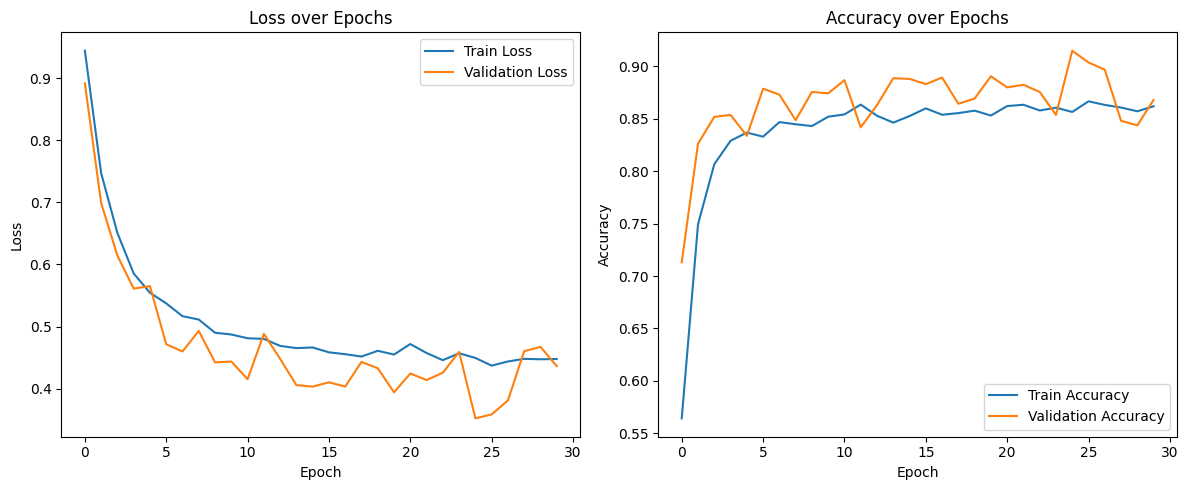

In [15]:
# Klassenungleichgewicht behandeln
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weight_dict = {i : class_weights[i] for i in range(len(class_weights))}
print("Klassen-Gewichte:", class_weight_dict)

# Modell kompilieren
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])

# EarlyStopping Callback
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Modell trainieren
history = model.fit(
    X_train_processed, y_train,
    epochs=50, # Eine höhere Anzahl von Epochen, da EarlyStopping dies steuert
    batch_size=32,
    validation_split=0.2, # 20% der Trainingsdaten für Validierung verwenden
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=1
)

# Trainingsverlauf plotten
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 6. Evaluation

Das trainierte Modell wird auf den **unberührten Testdaten** evaluiert, um die tatsächliche Leistung zu beurteilen. Es werden folgende Metriken ausgegeben:
- **Confusion Matrix**: Zeigt die Anzahl der korrekt und falsch klassifizierten Instanzen.
- **Classification Report**: Enthält Präzision, Recall und F1-Score für jede Klasse sowie den Support.
- **ROC-AUC Score**: Ein Maß für die Fähigkeit des Modells, positive und negative Klassen zu unterscheiden.


--- Modell-Evaluation auf den Testdaten ---
Test-Verlust: 0.3462
Test-Genauigkeit: 0.9190
Test-ROC-AUC-Score: 0.9489
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Confusion Matrix:
[[1782  150]
 [  12   56]]


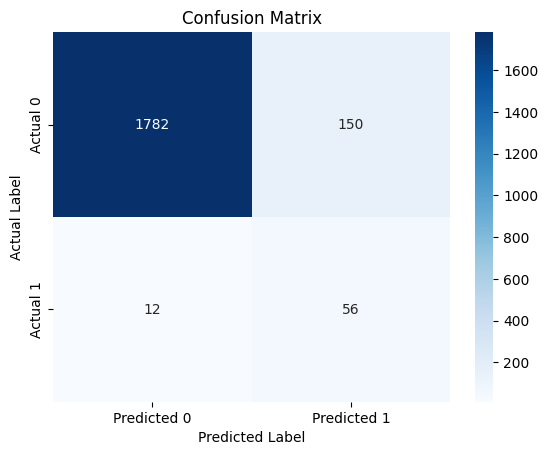


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.92      0.96      1932
           1       0.27      0.82      0.41        68

    accuracy                           0.92      2000
   macro avg       0.63      0.87      0.68      2000
weighted avg       0.97      0.92      0.94      2000



In [16]:
print("\n--- Modell-Evaluation auf den Testdaten ---")
loss, accuracy, auc = model.evaluate(X_test_processed, y_test, verbose=0)

print(f"Test-Verlust: {loss:.4f}")
print(f"Test-Genauigkeit: {accuracy:.4f}")
print(f"Test-ROC-AUC-Score: {auc:.4f}")

# Vorhersagen auf den Testdaten treffen
y_pred_proba = model.predict(X_test_processed)
y_pred = (y_pred_proba > 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### 7. SHAP Feature Importance

SHAP (SHapley Additive exPlanations) wird verwendet, um die Beiträge einzelner Features zu den Vorhersagen des Modells zu erklären. Ein Summary-Plot visualisiert die Wichtigkeit und den Einfluss der Features auf die Modellentscheidungen.


--- SHAP Feature Importance ---


/usr/local/lib/python3.13/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(100, 8))']
  warnings.warn(msg)
/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 8))']
  warnings.warn(msg)


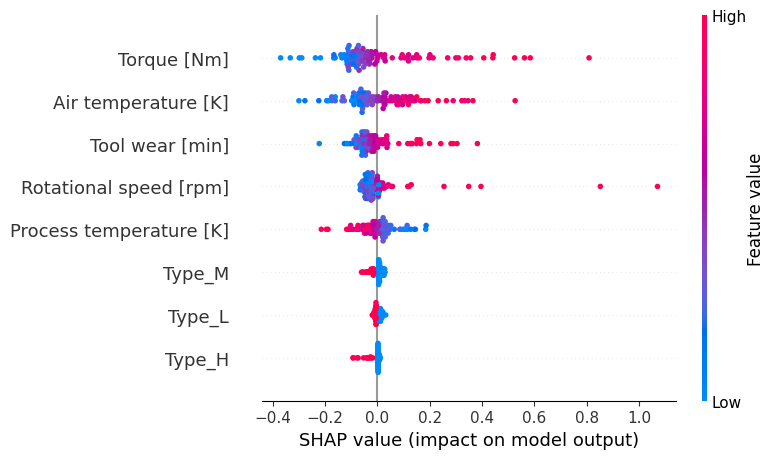

In [18]:
print("\n--- SHAP Feature Importance ---")

# Original feature names for processed data
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numerical_features + list(cat_feature_names)

# Create a Keras explainer with the model
explainer = shap.DeepExplainer(model, X_train_processed[:100]) # Use a subset of training data for background

# Calculate SHAP values for a subset of the test data
shap_values = explainer.shap_values(X_test_processed[:100])

# Plot the SHAP summary plot
# Ensure shap_values has a 2D shape (num_samples, num_features) by using .squeeze()
shap.summary_plot(shap_values.squeeze(), X_test_processed[:100], feature_names=all_feature_names)